Libraries loaded successfully.
 Dataset loaded: 5837 rows × 12 columns
DATASET OVERVIEW

Shape        : (5837, 12)
Duplicates   : 0

Column Data Types:
show_id          int64
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
type            object
dtype: object

Missing Values:
show_id            0
title              0
director        1901
cast             556
country          427
date_added       642
release_year       0
rating            10
duration           0
listed_in          0
description        0
type               0
dtype: int64


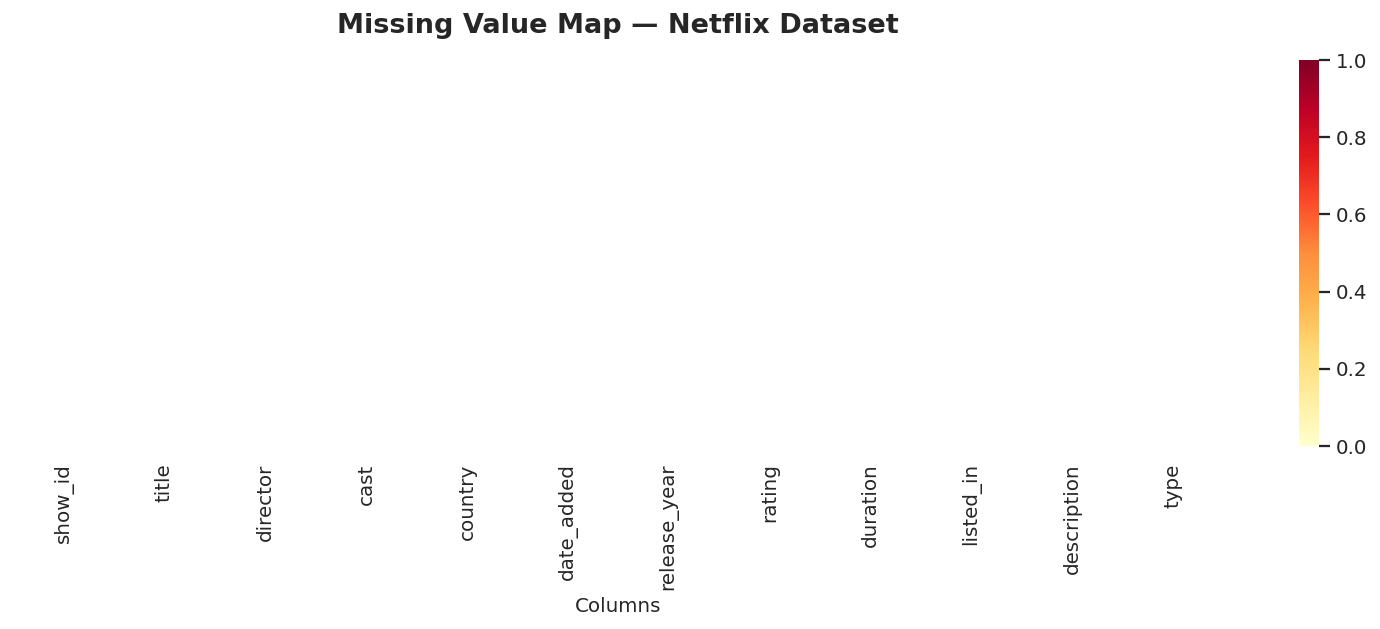

Chart saved: 01_missing_values_heatmap.png
Starting Data Cleaning...
  Duplicates removed : 0
   Missing values handled
   Date columns parsed
   Duration split into numeric + unit

 Cleaned Dataset Shape: (5195, 16)
Remaining Missing Values After Cleaning:
Series([], dtype: int64)


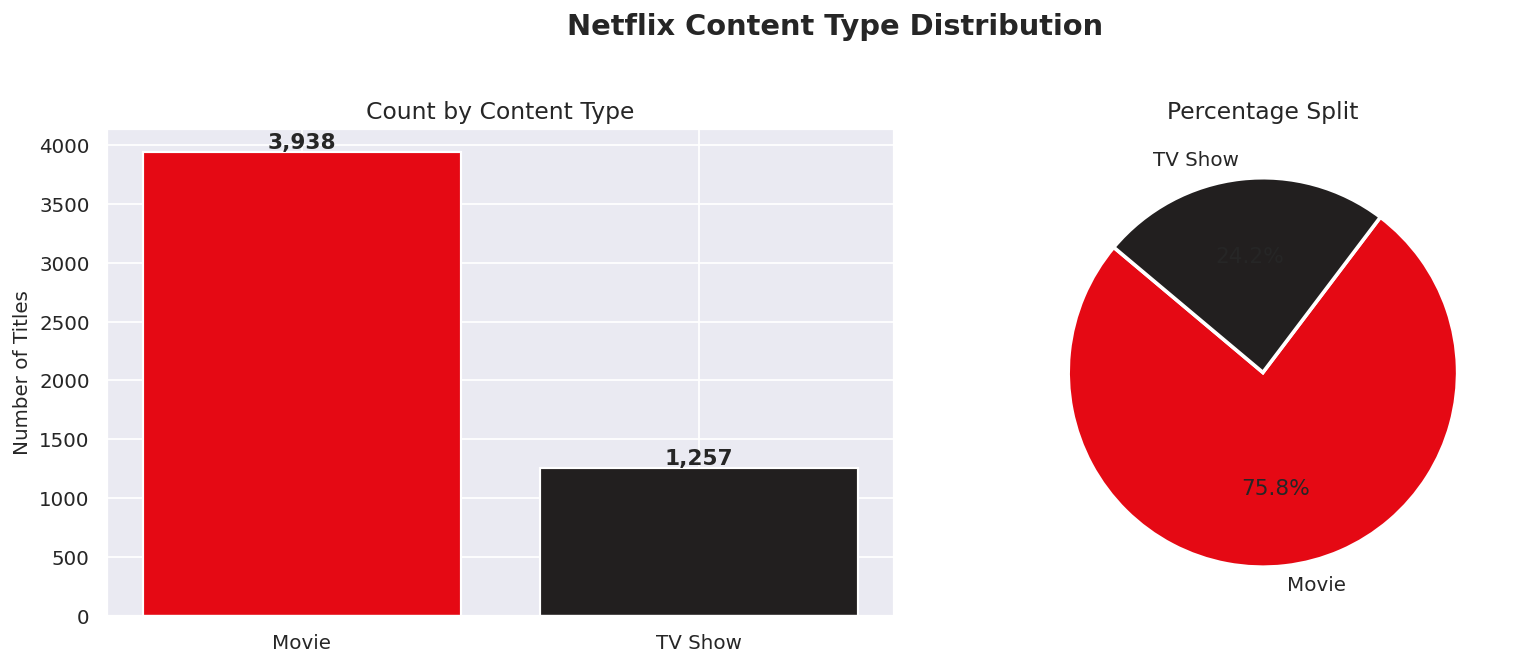

Chart saved: 02_content_type_distribution.png


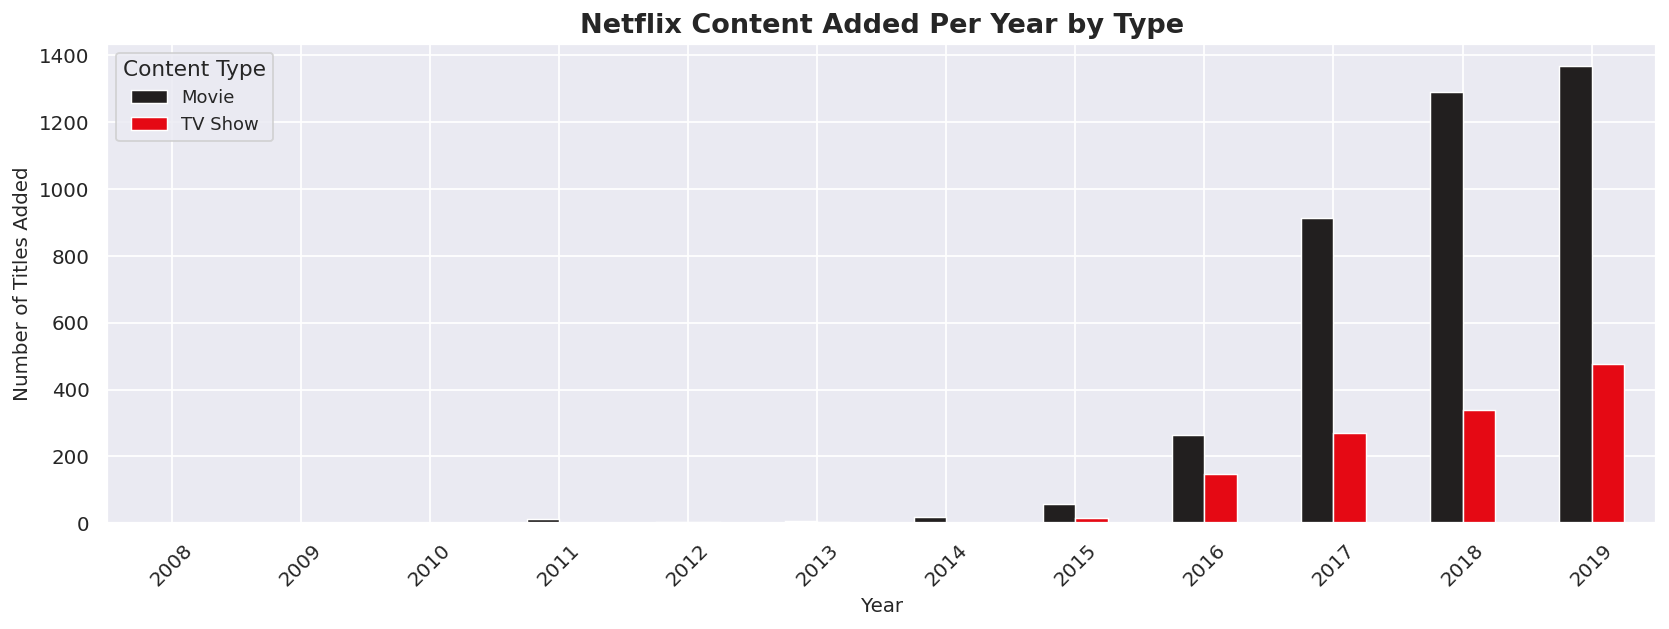

Chart saved: 03_content_added_per_year.png


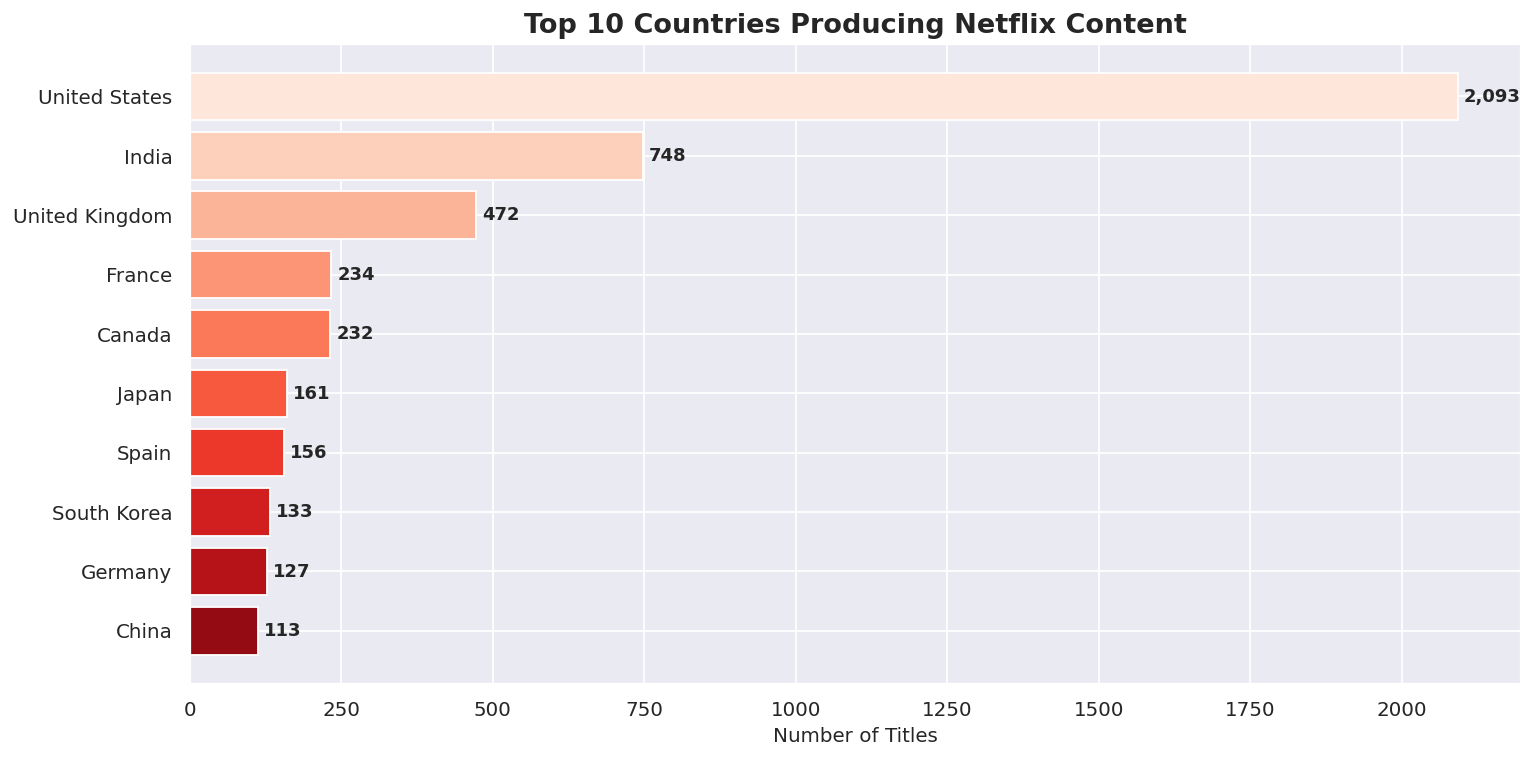

Chart saved: 04_top_countries.png


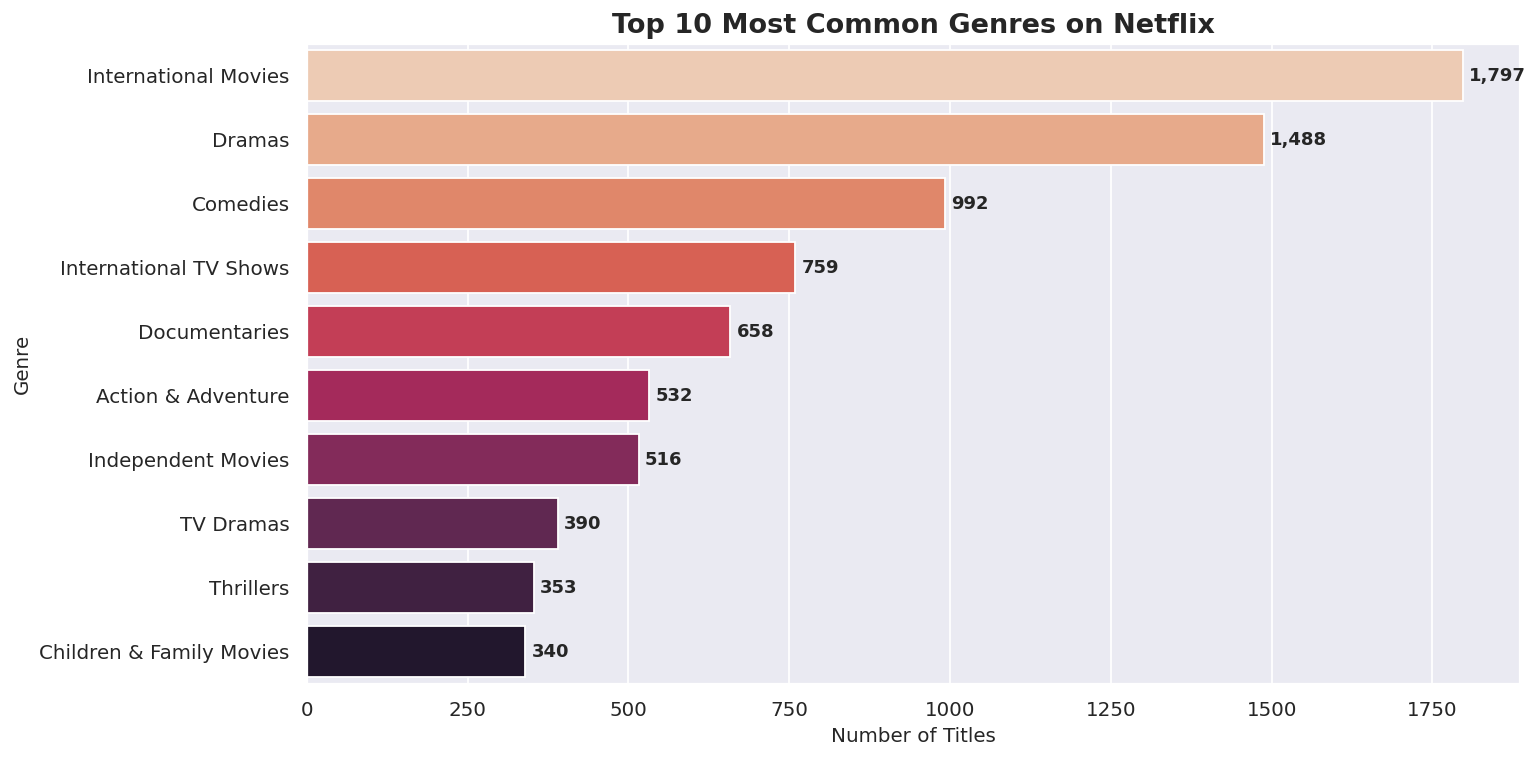

Chart saved: 05_top_genres.png


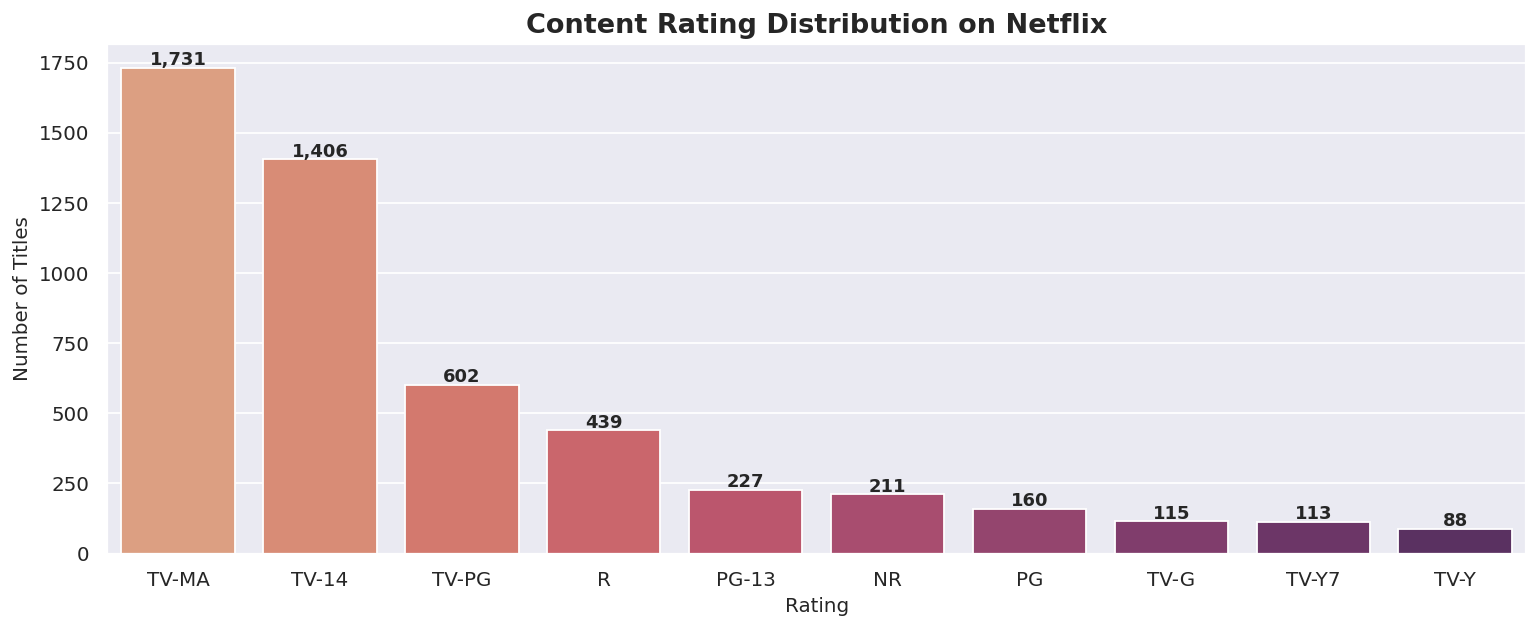

Chart saved: 06_rating_distribution.png


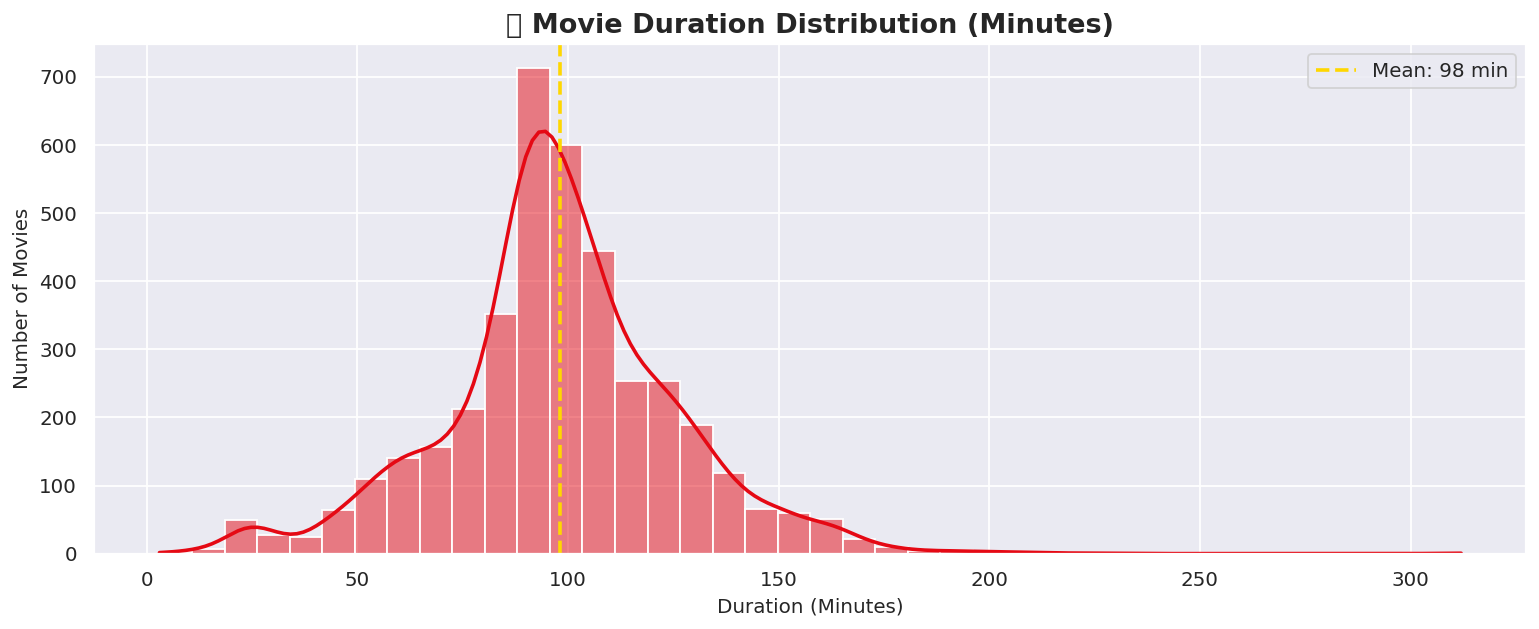

Chart saved: 07_movie_duration_distribution.png


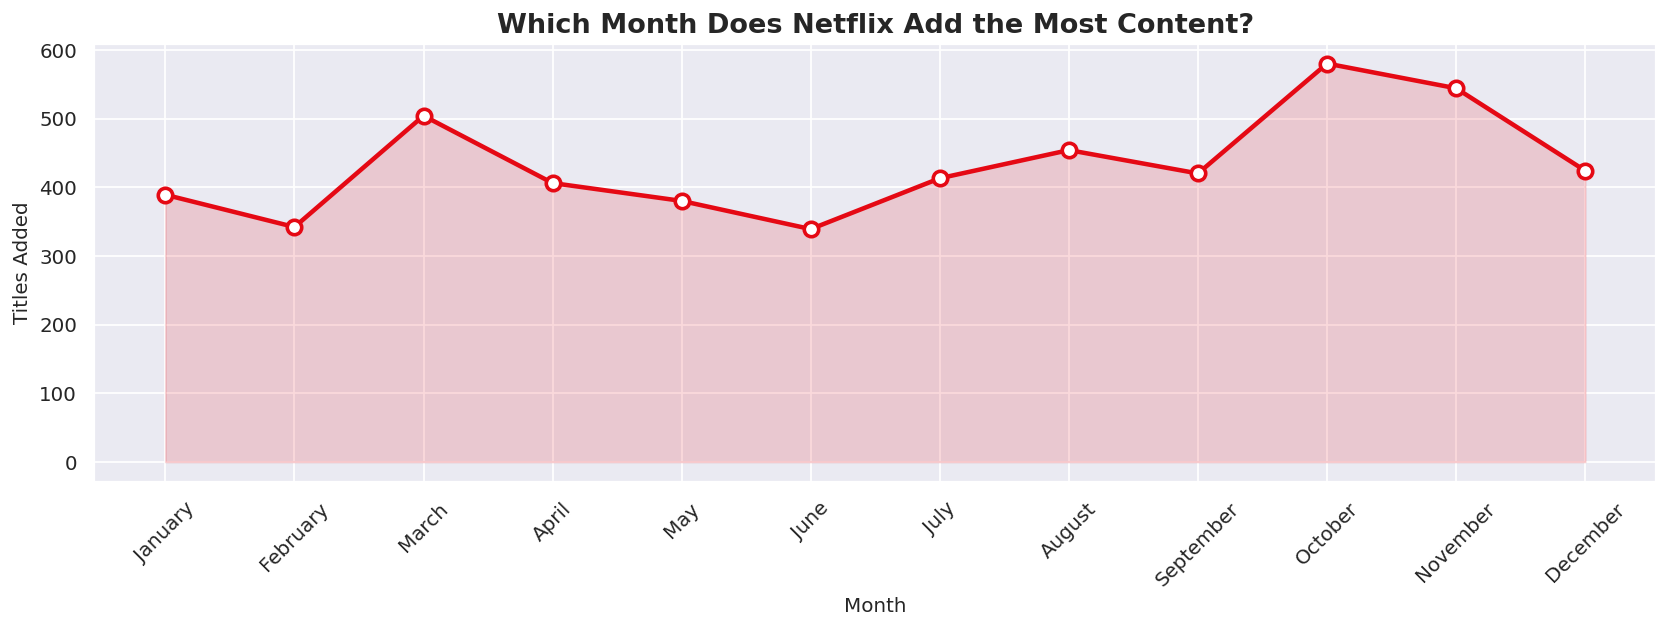

Chart saved: 08_monthly_content_trend.png


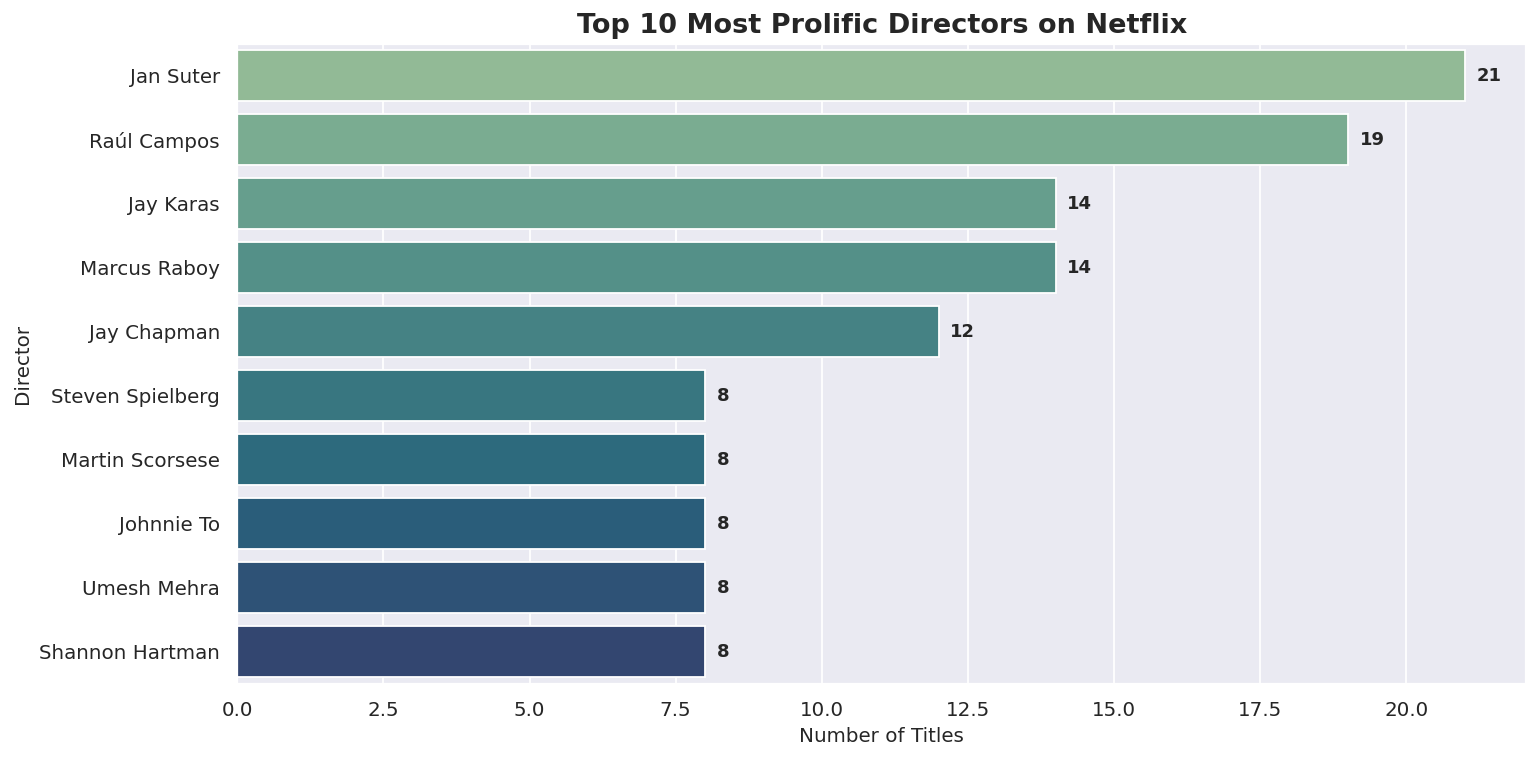

Chart saved: 09_top_directors.png
         KEY INSIGHTS — NETFLIX EDA SUMMARY

   Total Titles Analyzed     : 5,195
   Movies                    : 75.8% of catalog
   TV Shows                  : 24.2% of catalog
   Top Producing Country     : United States
   Most Common Genre         : International Movies
   Most Common Rating        : TV-MA
   Peak Content Year         : 2019
   Average Movie Duration    : 98.0 minutes

  Data Cleaning Steps Performed:
     • Removed duplicate records
     • Filled missing director, cast, country, rating fields
     • Parsed and standardized date_added column
     • Extracted year and month from date
     • Split duration into numeric value and unit

Project 1 Complete — Muhammad Iman Khan


In [3]:
# PROJECT 1: Netflix Movies & TV Shows — Data Cleaning & EDA
# Author: Muhammad Iman Khan
# Tools: Python, Pandas, Matplotlib, Seaborn
# Dataset: Netflix Shows (Kaggle - Shivam Bansal)

# - CELL 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries loaded successfully.")


# ─ CELL 2: Load Dataset
df = pd.read_csv('netflix_titles.csv')
print(f" Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


# ─ CELL 3: Initial Overview
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"\nShape        : {df.shape}")
print(f"Duplicates   : {df.duplicated().sum()}")
print(f"\nColumn Data Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())


# ─ CELL 4: Missing Value Heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True,
            cmap='YlOrRd', linewidths=0.3)
plt.title('Missing Value Map — Netflix Dataset', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Columns', fontsize=11)
plt.tight_layout()
plt.savefig('01_missing_values_heatmap.png', bbox_inches='tight')
plt.show()
print("Chart saved: 01_missing_values_heatmap.png")


# ─ CELL 5: Data Cleaning
print("Starting Data Cleaning...")

# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"  Duplicates removed : {before - len(df)}")

# Fill missing values
df['director'].fillna('Unknown Director', inplace=True)
df['cast'].fillna('Unknown Cast', inplace=True)
df['country'].fillna('Unknown Country', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['duration'].fillna('Unknown', inplace=True)
df.dropna(subset=['date_added'], inplace=True)

# Fix date formats
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Fix duration
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z]+)')

print(f"   Missing values handled")
print(f"   Date columns parsed")
print(f"   Duration split into numeric + unit")
print(f"\n Cleaned Dataset Shape: {df.shape}")
df.head(3)


# ─ CELL 6: Missing Values After Cleaning
print("Remaining Missing Values After Cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


# ─ CELL 7: Content Type Distribution
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Netflix Content Type Distribution', fontsize=16, fontweight='bold', y=1.02)

# Bar chart
colors = ['#E50914', '#221F1F']
axes[0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Count by Content Type', fontsize=13)
axes[0].set_ylabel('Number of Titles', fontsize=11)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage Split', fontsize=13)

plt.tight_layout()
plt.savefig('02_content_type_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved: 02_content_type_distribution.png")


# ─ CELL 8: Content Added Per Year
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(13, 5))
yearly.plot(kind='bar', color=['#221F1F', '#E50914'],
            edgecolor='white', linewidth=0.8, ax=plt.gca())
plt.title('Netflix Content Added Per Year by Type', fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Number of Titles Added', fontsize=11)
plt.xticks(rotation=45)
plt.legend(title='Content Type', fontsize=10)
plt.tight_layout()
plt.savefig('03_content_added_per_year.png', bbox_inches='tight')
plt.show()
print("Chart saved: 03_content_added_per_year.png")


# ─ CELL 9: Top 10 Countries
top_countries = (df[df['country'] != 'Unknown Country']
                 ['country']
                 .str.split(', ')
                 .explode()
                 .value_counts()
                 .head(10))

plt.figure(figsize=(12, 6))
bars = plt.barh(top_countries.index[::-1], top_countries.values[::-1],
                color=sns.color_palette("Reds_r", 10), edgecolor='white')
plt.title('Top 10 Countries Producing Netflix Content', fontsize=15, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=11)
for bar, val in zip(bars, top_countries.values[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('04_top_countries.png', bbox_inches='tight')
plt.show()
print("Chart saved: 04_top_countries.png")


# ─ CELL 10: Top 10 Genres
genres = (df['listed_in']
          .str.split(', ')
          .explode()
          .value_counts()
          .head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=genres.values, y=genres.index,
            palette='rocket_r', edgecolor='white')
plt.title('Top 10 Most Common Genres on Netflix', fontsize=15, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=11)
plt.ylabel('Genre', fontsize=11)
for i, v in enumerate(genres.values):
    plt.text(v + 10, i, f'{v:,}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('05_top_genres.png', bbox_inches='tight')
plt.show()
print("Chart saved: 05_top_genres.png")


# ─ CELL 11: Rating Distribution
rating_order = (df['rating'].value_counts()
                .sort_values(ascending=False)
                .head(10))

plt.figure(figsize=(12, 5))
sns.barplot(x=rating_order.index, y=rating_order.values,
            palette='flare', edgecolor='white')
plt.title('Content Rating Distribution on Netflix', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=11)
plt.ylabel('Number of Titles', fontsize=11)
for i, v in enumerate(rating_order.values):
    plt.text(i, v + 10, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('06_rating_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved: 06_rating_distribution.png")


# ─ CELL 12: Movie Duration Distribution
movies = df[(df['type'] == 'Movie') & (df['duration_int'].notna())]

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(movies['duration_int'], bins=40,
             color='#E50914', edgecolor='white', kde=True,
             line_kws={'color': '#221F1F', 'linewidth': 2}, ax=ax)
ax.axvline(movies['duration_int'].mean(), color='gold',
           linestyle='--', linewidth=2,
           label=f"Mean: {movies['duration_int'].mean():.0f} min")
ax.set_title('⏱ Movie Duration Distribution (Minutes)', fontsize=15, fontweight='bold')
ax.set_xlabel('Duration (Minutes)', fontsize=11)
ax.set_ylabel('Number of Movies', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('07_movie_duration_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved: 07_movie_duration_distribution.png")


# ─ CELL 13: Monthly Content Addition Trend
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df['month_added'].value_counts().reindex(month_order)

plt.figure(figsize=(13, 5))
plt.plot(monthly.index, monthly.values, marker='o',
         color='#E50914', linewidth=2.5, markersize=8,
         markerfacecolor='white', markeredgewidth=2)
plt.fill_between(monthly.index, monthly.values, alpha=0.15, color='#E50914')
plt.title('Which Month Does Netflix Add the Most Content?',
          fontsize=15, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Titles Added', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('08_monthly_content_trend.png', bbox_inches='tight')
plt.show()
print("Chart saved: 08_monthly_content_trend.png")


# ─ CELL 14: Top 10 Directors
top_directors = (df[df['director'] != 'Unknown Director']
                 ['director']
                 .str.split(', ')
                 .explode()
                 .value_counts()
                 .head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_directors.values, y=top_directors.index,
            palette='crest', edgecolor='white')
plt.title('Top 10 Most Prolific Directors on Netflix',
          fontsize=15, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=11)
plt.ylabel('Director', fontsize=11)
for i, v in enumerate(top_directors.values):
    plt.text(v + 0.2, i, str(v), va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('09_top_directors.png', bbox_inches='tight')
plt.show()
print("Chart saved: 09_top_directors.png")


# ─ CELL 15: Key Insights Summary
print("=" * 60)
print("         KEY INSIGHTS — NETFLIX EDA SUMMARY")
print("=" * 60)

total = len(df)
movies_pct = round(len(df[df['type'] == 'Movie']) / total * 100, 1)
shows_pct = round(len(df[df['type'] == 'TV Show']) / total * 100, 1)
top_country = df[df['country'] != 'Unknown Country']['country'].str.split(', ').explode().value_counts().index[0]
top_genre = df['listed_in'].str.split(', ').explode().value_counts().index[0]
top_rating = df['rating'].value_counts().index[0]
peak_year = df['year_added'].value_counts().index[0]
avg_movie_dur = round(movies['duration_int'].mean(), 1)

print(f"""
   Total Titles Analyzed     : {total:,}
   Movies                    : {movies_pct}% of catalog
   TV Shows                  : {shows_pct}% of catalog
   Top Producing Country     : {top_country}
   Most Common Genre         : {top_genre}
   Most Common Rating        : {top_rating}
   Peak Content Year         : {int(peak_year)}
   Average Movie Duration    : {avg_movie_dur} minutes

  Data Cleaning Steps Performed:
     • Removed duplicate records
     • Filled missing director, cast, country, rating fields
     • Parsed and standardized date_added column
     • Extracted year and month from date
     • Split duration into numeric value and unit
""")
print("=" * 60)
print("Project 1 Complete — Muhammad Iman Khan")
print("=" * 60)